In [417]:
# Imports
## Basic imports
import numpy as np
import xarray as xr
import utils

## Math imports
from scipy.optimize import brentq
from scipy.stats import exponnorm
from numpy.fft import rfftfreq, rfft

## Plotting
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

## Optimization
import jax
import jax.numpy as jnp
from jax.example_libraries import optimizers

## Setup plot defaults
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Two region EBM for preliminary testing

In [866]:
class two_region_ebm:
  def __init__(self, T_calibrate, F_calibrate, verbose=False):
    self.dt = 1
    self.C1, self.C2, self.delta, self.lam, self.D = self.calibrate(T_calibrate, F_calibrate)
    self.A, self.B = self.generate_matrices()
    self.scenarios = {}

    if verbose:
      print(self.__str__())

  def __str__(self):
    return f'C1 = {round(self.C1, 4)}, C2 = {round(self.C2, 4)}, delta = {round(self.delta, 4)}, lam = {round(self.lam, 4)}, D = {round(self.D, 4)}'

  def calibrate(self, T_calibrate, F_calibrate, num_steps = 5_000, lr = 1e-3):
    init_params = jnp.array([0.6, 190.0, 0.18, 0.86, 0.44])
    F_interp, Nt_interp = utils.interpolate(F_calibrate, self.dt)
    T_interp, Nt_interp = utils.interpolate(T_calibrate, self.dt)

    def forward_model(params, F):
      C1, C2, delta, lam, D = params
      C = jnp.array([C1, C2]) / self.dt
      T0 = jnp.array([0.0, 0.0])
      Nt = len(F)

      A = jnp.array([[D - lam/(0.5 + delta), -D],[-D, D]])
      B = jnp.array([1.0, 1.0])

      def step(T_prev, F_n):
        rhs = (A @ T_prev + B * F_n) / C
        T_new = T_prev + self.dt * rhs
        return T_new, T_new

      T_final, T_series = jax.lax.scan(step, T0, F)

      return T_series.T

    def loss_fn(params):
      params = utils.apply_constraints(params)
      T_out = forward_model(params, F_interp)
      T_model = (0.5 + params[2])*T_out[0,:] + (0.5 - params[2])*T_out[1,:]
      return jnp.linalg.norm(T_model - T_interp, ord=2)

    opt_init, opt_update, get_params = optimizers.adam(lr)
    opt_state = opt_init(init_params)

    @jax.jit
    def one_step(i, state):
      params = get_params(state)
      val, grads = jax.value_and_grad(loss_fn)(params)
      new_state = opt_update(i, grads, state)
      return new_state, val

    state = opt_state
    for i in range(num_steps):
      state, cur_loss = one_step(i, state)

    opt_params = get_params(state)
    opt_params = utils.apply_constraints(opt_params)

    return opt_params

  def generate_matrices(self):

    A = jnp.array([[self.D - self.lam/(0.5 + self.delta), -self.D],[-self.D, self.D]])
    B = jnp.array([[1.0, 0.0], [0.0, 1.0]])

    return A, B

  def run_scenario(self, scenario_name, F, T0):
    if len(F.shape) == 1:
      Nb, Nt = 2, len(F)
      F = np.tile(F, (Nb, 1))
    else:
      Nb, Nt = F.shape
    C = np.array([self.C1, self.C2]) / self.dt

    F_interp, Nt_interp = utils.interpolate(F, self.dt)

    T_out = np.empty((Nb, Nt_interp))
    T_out[:,0] = T0

    for n in range(1, Nt_interp):
      rhs = (self.A @ T_out[:, n - 1] + self.B @ F_interp[:, n - 1]) / C
      T_out[:,n] = T_out[:, n - 1] + self.dt * rhs

    self.scenarios[scenario_name] = T_out

    return

  def plot_scenarios(self, scenario_names, plot_global_avg=False, tas_true=None):
    Ns = len(scenario_names)
    fig, ax = plt.subplots(1, Ns)

    for scenario_name in scenario_names:
      tas_region = self.scenarios[scenario_name]
      tas_global = (0.5 + self.delta)*tas_region[0,:] + (0.5 - self.delta)*tas_region[1,:]
      ax.plot(tas_region[0,:], lw=2, label='Land')
      ax.plot(tas_region[1,:], lw=2, label='Ocean')

      if plot_global_avg:
        ax.plot(tas_global, lw=2, label='Global Avg.')

      if tas_true is not None:
        tas_true_plot, N_interp = utils.interpolate(tas_true, self.dt)
        ax.plot(tas_true_plot, lw=2, label='Truth')

    ax.legend()

    return

## Baseline Testing

#### Load MPI data and calibrate box model

In [823]:
ERF_calibrate_ds_path = 'data/MPI/historical/historical_ERF_global_anomaly.nc4'
tas_calibrate_ds_path = 'data/MPI/historical/historical_tas_global_anomaly.nc4'
ERF_calibrate_ds = xr.open_dataset(ERF_calibrate_ds_path)
tas_calibrate_ds = xr.open_dataset(tas_calibrate_ds_path)
ERF_calibrate_np = ERF_calibrate_ds.ERF.values
tas_calibrate_np = tas_calibrate_ds.tas.values

C1 = 4.641599655151367, C2 = 185.38619995117188, delta = 0.2475999891757965, lam = 1.3115999698638916, D = 0.17319999635219574


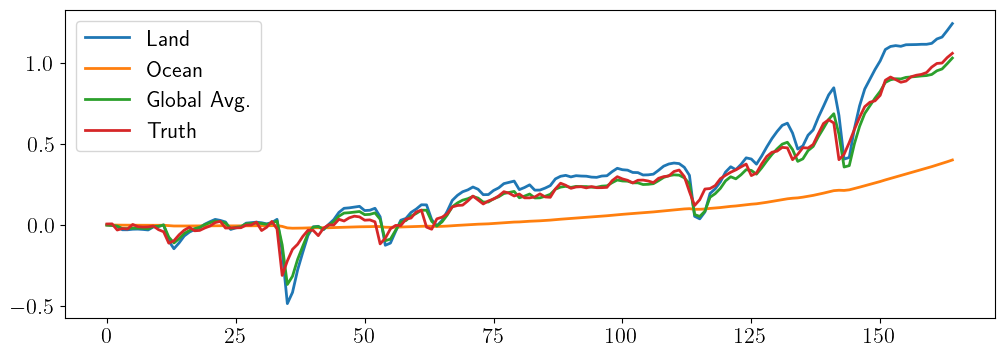

In [867]:
test_two = two_region_ebm(tas_calibrate_np, ERF_calibrate_np, verbose=True)
test_two.run_scenario('MPI_historical', ERF_calibrate_np, np.array([0,0]))
test_two.plot_scenarios(['MPI_historical'], plot_global_avg=True, tas_true=tas_calibrate_np)

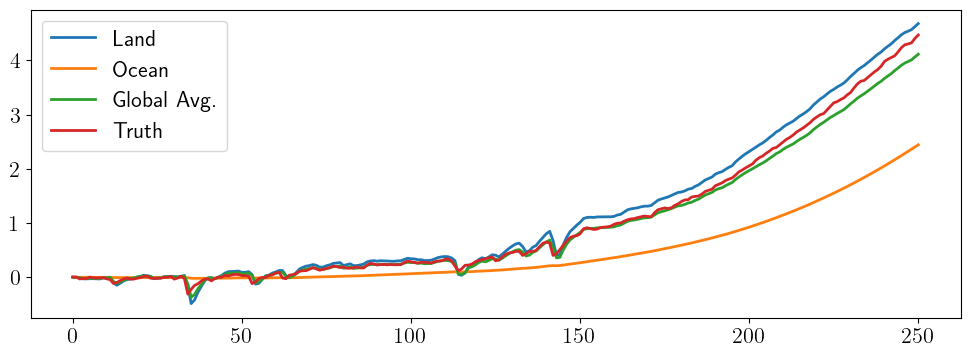

In [868]:
tas_test_ds_path = 'data/MPI/historical/historical_ssp585_tas_global_anomaly.nc4'
tas_test_ds = xr.open_dataset(tas_test_ds_path)
tas_test_np = tas_test_ds.tas.values
ERF_test_ds_path = 'data/MPI/historical/historical_ssp585_ERF_global_anomaly.nc4'
ERF_test_ds = xr.open_dataset(ERF_test_ds_path)
ERF_test_np = ERF_test_ds.ERF.values

scenario_names = ['MPI_ssp585']
test_two.run_scenario('MPI_ssp585', ERF_test_np, np.array([0,0]))
test_two.plot_scenarios(scenario_names, plot_global_avg=True, tas_true=tas_test_np)

#### Forcing definitions
Traditional scenarios:
1. Abrupt
2. SSP585 (w/ historical)
3. SSP119 (w/ historical)

Idealized scenarios:
1. Pseudo-impulse
2. Noise
3. Sine sweep

Training scenarios:
1. Interpolation, SSP245
2. Rebound, longer scenario w/ plateau by end of century, but then we cross a tipping point (Amazon dieback? permafrost melt?) and massive emissions increases
3. Geoengineering, longest scenario w/ rapid drop to negative anomaly, followed by increase as developing nations emit as much as they want

In [887]:
from scipy.ndimage import gaussian_filter1d

sigma = 2
smoothed_data = gaussian_filter1d(ERF_test_np, sigma)

In [891]:
for ssp in ['119','126','245','370','585']:
  tas_ds_path = f'data/MPI/historical_ssp/historical_ssp{ssp}_tas_global_anomaly.nc4'
  tas_ds = xr.open_dataset(tas_ds_path)
  tas_np = tas_ds.tas.values
  ERF_ds_path = f'data/MPI/historical_ssp/historical_ssp{ssp}_ERF_global_anomaly.nc4'
  ERF_ds = xr.open_dataset(ERF_ds_path)
  ERF_np = ERF_ds.ERF.values

  tas_smooth = gaussian_filter1d(tas_np, sigma)
  ERF_smooth = gaussian_filter1d(ERF_np, sigma)

  utils.save_results(tas_smooth, f'data/MPI/historical_ssp_smooth/historical_ssp{ssp}_tas_global_anomaly_smooth')
  utils.save_results(ERF_smooth, f'data/MPI/historical_ssp_smooth/historical_ssp{ssp}_ERF_global_anomaly_smooth')

In [948]:
def forcing_abrupt(F0, Nb, Nt):
  return F0*np.ones((Nb, Nt))

def forcing_historical(Nb):
  # Historical ERF values approximated from:
  # https://agupubs.onlinelibrary.wiley.com/doi/pdfdirect/10.1029/2023GL104848 (Figure 1)
  # (0, 0.3) from (1850, 1970) and then (0.3, 2.4) from (1970, 2014)
  F_1850, F_1970, F_2015 = 0, 0.5, 2.1
  Nt_1850_1970 = 1970 - 1850
  Nt_1970_2015 = 2015 - 1970
  F_era1, F_era2 = np.linspace(F_1850, F_1970, Nt_1850_1970), np.linspace(F_1970, F_2015, Nt_1970_2015)
  return np.tile(np.concatenate([F_era1, F_era2]), (Nb, 1))

def forcing_SSP585(Nb):
  # Future SSP585 values approximated from:
  # https://esd.copernicus.org/articles/12/253/2021/esd-12-253-2021.html#&gid=1&pid=1 (Figure A7)
  F_2015, F_2100 = 2.1, 8.5
  Nt_2015_2100 = 2100 - 2015
  return np.tile(np.linspace(F_2015, F_2100, Nt_2015_2100), (Nb, 1))

def get_hist_ssp_smooth(ssp, Nb):
  F_ssp_smooth_np = utils.open_results(f'data/MPI/historical_ssp_smooth/historical_ssp{ssp}_ERF_global_anomaly_smooth')
  return np.tile(F_ssp_smooth_np, (Nb, 1))

def get_hist_ssp_smooth_local(ssp, Nb):
  t_vec = np.arange(1850, 2101)

  if Nb == 2:
    F_total = get_hist_ssp_smooth(ssp, Nb)
    F_local = np.zeros_like(F_total)
    F_global_unscaled = np.zeros_like(F_total)

    if ssp == '370':
      F_final = 7.0
      for i, t in enumerate(t_vec):
        if t < 2015:
          F_local[0,i] = (-np.exp((t - 1850)/250) + 1)*(4/5*np.sin((t - 10)/30) + 1.75)
        else:
          F_local[0,i] = (-np.exp((2015 - 1850)/250) + 1)*(4/5*np.sin((2015 - 10)/30) + 1.75)
    else:
      raise ValueError(f'Error, ssp{ssp} not implemented.')

    # Extract well-mixed component
    F_well_mixed = F_total[0,:] - F_local[0,:]

    # The oceanic box only sees this well_mixed forcing
    F_global_unscaled[1,:] = F_well_mixed

    # The land box sees the total w/ aerosols
    F_global_unscaled[0,:] = F_total[0,:]

    # This may have thrown off our values though, need to make sure the avg
    # forcing globally is still the same total forcing
    F_avg_unscaled = (F_global_unscaled[0,-1] + F_global_unscaled[1,-1])/2
    scaling_factor = F_avg_unscaled/F_final
    F_global = F_global_unscaled/scaling_factor

  else:
    raise ValueError(f'Error, Nb = {Nb} not implemented.')

  return F_global


F0_abr = 3.7
Nb = 2
Nt = 250
F_abr = forcing_abrupt(F0_abr, Nb, Nt)

In [949]:
F_ssp370 = get_hist_ssp_smooth_local('370', Nb)

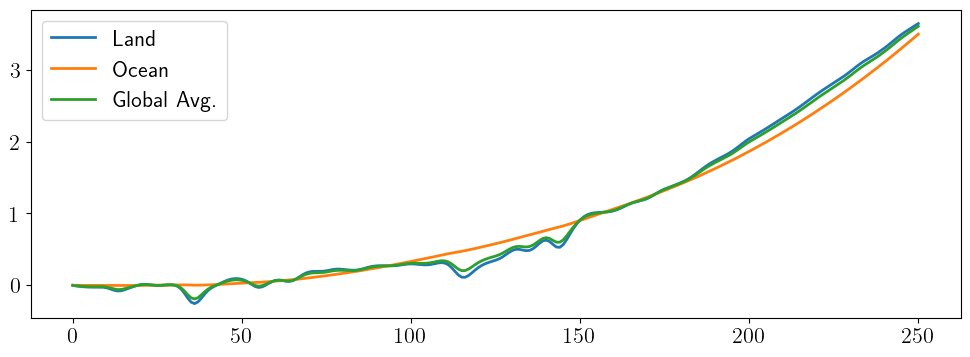

In [952]:
scenario_names = ['ssp370']
test_two.run_scenario('ssp370', F_ssp370, np.array([0,0]))
test_two.plot_scenarios(scenario_names, plot_global_avg=True)

In [953]:
def _toeplitz_rank(u, L):
  m, N  = u.shape
  Hcols = N - L + 1
  H = np.vstack([u[:, i:i+Hcols] for i in range(L)])
  return np.linalg.matrix_rank(H)

In [958]:
_toeplitz_rank(F_ssp370, 2)

np.int64(4)

In [172]:
class three_box_ebm:
  def __init__(self, lam, C, D, T0, dt):
    self.C    = C                     # Heat capacity [J kg-1 K-1]
    self.D    = D                     # Diffusivity [W m-2 K-1]
    self.dt   = dt                    # Time step [seconds]
    self.lam  = self.make_lam(lam, D) # Feedback parameter [W m-2 K-1]
    self.T0   = T0                    # Initial temperature [K]

  def make_lam(self, lam_diag, D=0.0):
    lam = np.asarray(lam_diag, dtype=float)
    lam = np.diag(lam)

    if D != 0.0:
      lam += np.diag([D, 2*D, D])
      lam[0, 1] = lam[1, 0] = -D
      lam[1, 2] = lam[2, 1] = -D

    return lam

  def box_iter(self, F, Nt_year):
    Nt_sec = int(Nt_year * 3600 * 24 * 365.24 / self.dt)
    T_out, T_integrate = np.empty((3, Nt_year + 1)), np.empty((3, Nt_sec))

    T_out[:, 0], T_integrate[:, 0] = self.T0, self.T0
    B = np.eye(len(self.C))

    i_save = 1
    for n in range(1, Nt_sec):
      try:
        Ft = F(n - 1)
      except:
        Ft = F[:,n - 1]

      RHS = 1 / self.C * (-self.lam @ T_integrate[:, n - 1] + B @ Ft)
      T_integrate[:, n] = T_integrate[:, n - 1] + self.dt * RHS

      if n % 365 == 0:
        T_out[:, i_save] = T_integrate[:, n]
        i_save += 1

    return T_out

  def plot_box(self, T_out):
    plt.plot(T_out.T)
    return

In [269]:
C/(3600 * 24 * 365.25)

array([190.12852688,   0.63376176,  19.01285269])

In [267]:
# Required constants
rho_w = 1e3                         # Water density [kg m-3]
cp_w = 4e3                          # Water specific heat capacity [J kg-1 K-1]
h = np.array([1500, 5, 150])       # Water slab thickness [m]
C = h * rho_w * cp_w                # Effective heat capacity [J m-2 K-1]
D = 0.55
lam_diag = np.array([0.67, 0.86, 2.0]) # Feedback parameters [W m-2 K-1]
T0 = np.zeros(3)
dt = 3600 * 24

Nt_year = 250

box_test = three_box_ebm(lam_diag, C, D, T0, dt)
F_abr = lambda t: 3.7 * np.ones(3)
#F_abr = lambda t: np.array([0, 0, 3.7])
T_out_abr = box_test.box_iter(F_abr, Nt_year)

In [180]:
np.linalg.matrix_rank(T_out_abr)

np.int64(3)

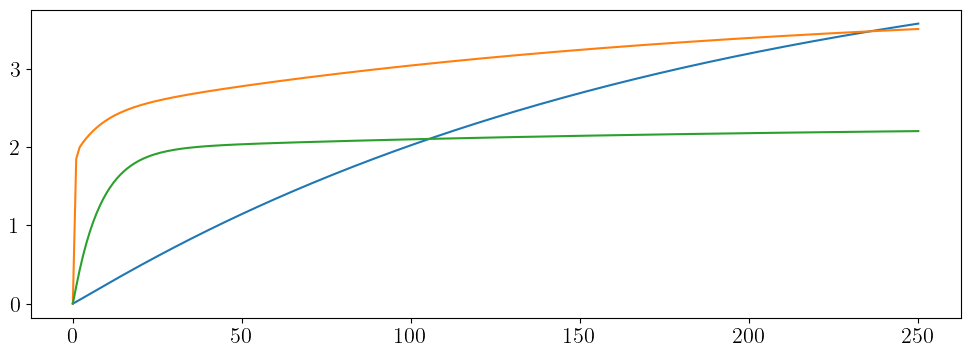

In [175]:
box_test.plot_box(T_out_abr)

## Setup CMIP-like forcings

## Test criteria

In [979]:
def check_I_controllable(A, B, tol=1e-9):
  n = A.shape[0]
  R = np.hstack([np.linalg.matrix_power(A, k) @ B for k in range(n)])
  return np.linalg.matrix_rank(R) == n



def check_II_PE(u, n, order_factor=2, tol=1e-9):
  L = order_factor * n
  print(_toeplitz_rank(u, L))
  return _toeplitz_rank(u, L) >= L * u.shape[0] - tol


In [97]:
F_abr_mat = np.vstack([F_abr(t) for t in range(Nt_year)]).T

In [980]:
print('\tPersistently Exciting:', check_II_PE(F_ssp370, n=2))

8
	Persistently Exciting: True


In [977]:
print('\tPersistently Exciting:', check_II_PE(F_exp, n=box_test.lam.shape[0]))

100
	Persistently Exciting: False


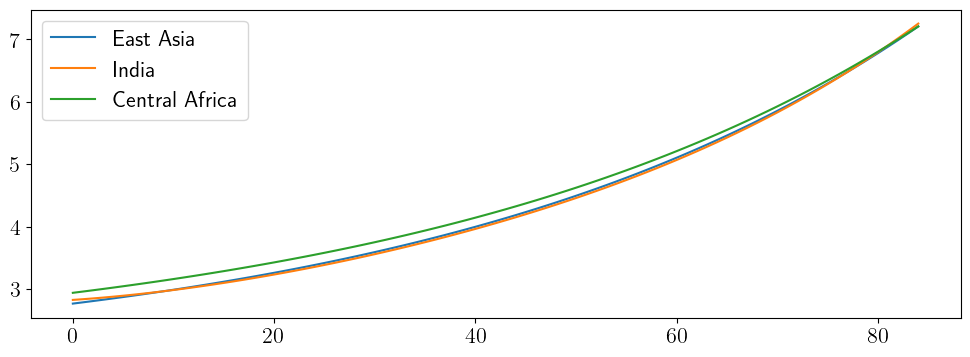

In [722]:
labels = ['East Asia','India','Central Africa']
for i in range(len(F_exp)):
  plt.plot(F_exp[i,:], label=labels[i])
plt.legend()

In [121]:
def _box_mask(boxes, n_boxes=3):
  return np.asarray(boxes, dtype=float)[:, None]


In [163]:
0.5/aer_east_asia_ssp370[-1]/3

np.float64(0.53222784)

In [720]:
def gen_exponential(F_final, t, t_end, t_star, Nb):
  a = F_final/np.exp(t_end/t_star)
  F = np.tile(a*np.exp(t/t_star), (Nb, 1))

  return F

F_exp = gen_exponential(5.5, np.arange(0, 85), 85, 50, 3) + 2.0 # SSP370-ish
aerosol_ERF_tot = -0.5 # End of century total ERF from aerosols [W m-2]

N_year = 85
aer_east_asia_ssp370 = np.array([-0.00000001*(t - 20)**4 + 0.7 for t in range(N_year)])
aer_india_ssp370 = np.array([-0.00000008*(t - 40)**4 + 0.6 for t in range(N_year)])
aer_central_africa_ssp370 = np.array([0.00005*(t)**2 + 0.2 for t in range(N_year)])
F_exp[0,:] -= (aer_east_asia_ssp370*(0.5/aer_east_asia_ssp370[-1]*(4/11)))
F_exp[1,:] -= (aer_india_ssp370*(0.5/aer_india_ssp370[-1]*(3/11)))
F_exp[2,:] -= (aer_central_africa_ssp370*(0.5/aer_central_africa_ssp370[-1]*(4/11)))


#F_pseudo = forcing_pseudo_impulse(85, width=10, box=[0.5,0.75,1])

In [725]:
def _flatten(arr):
    arr = np.asarray(arr)
    return arr.reshape(arr.shape[0], -1)

def check_richness(F_in, tol=1e-10):
    F_in = _flatten(F_in)               # (3 , N_total)

    # ---------- input condition (input covariance full-rank) ----------
    Ru = F_in @ F_in.T / F_in.shape[1]          # ∫u uᵀ dt  (discrete mean)
    rank_input = np.linalg.matrix_rank(Ru, tol)

    return rank_input, (rank_input == 3)

In [726]:
check_richness(F_exp)

(np.int64(3), np.True_)

In [177]:
T_out_exp = box_test.box_iter(F_exp, 85)

IndexError: index 85 is out of bounds for axis 1 with size 85

### 2) Realistic (CMIP-like) Forcings

In [120]:





def gen_overshoot(F_peak, F_end, t_vec, t_peak, K, Nb, mask=None, tol=1e-6):

  def series(sigma):
    emg_raw = exponnorm.pdf(t_vec, K, loc=t_peak, scale=sigma)
    emg0    = exponnorm.pdf(0,  K, loc=t_peak, scale=sigma)
    raw     = emg_raw - emg0               # baseline-correct
    amp     = 1.0 / raw.max()              # scale so *actual* peak = 1
    return amp * raw

  def residual(sigma):
    return F_peak*series(sigma)[-1] - F_end

  sig_lo, sig_hi = 1e-3, 10*len(t_vec)
  if residual(sig_lo) * residual(sig_hi) > 0:        # infeasible combo
    raise ValueError("Requested end_value cannot be reached with this K."
                      " Try lowering end_value, choosing a later peak_year,"
                      " or increasing K for a fatter tail.")
  sigma_opt = brentq(residual, sig_lo, sig_hi, xtol=tol)
  F = np.tile(F_peak*series(sigma_opt), (Nb, 1))

  if mask is not None:
    F *= _box_mask(mask)

  return F

F_abrupt_wm = gen_abrupt(3.7, t_vec, 3)
F_abrupt_sp = gen_abrupt(3.7, t_vec, 3, mask=[0.75, 1.25, 0.5])
T_abrupt_wm = three_box_ebm(C, Lam, F_abrupt_wm, t_vec)
T_abrupt_sp = three_box_ebm(C, Lam, F_abrupt_sp, t_vec)

F_585_wm = gen_exponential(8.5, t_vec, 85, 55, 3)
F_585_sp = gen_exponential(8.5, t_vec, 85, 55, 3, mask=[1, 1.5, 0.65])
T_585_wm = three_box_ebm(C, Lam, F_585_wm, t_vec)
T_585_sp = three_box_ebm(C, Lam, F_585_sp, t_vec)

F_534_wm = gen_overshoot(6, 3.4, t_vec, 18, 3, 3)
F_534_sp = gen_overshoot(6, 3.4, t_vec, 18, 3, 3, mask=[0.75, 1.4, 0.75])
T_534_wm = three_box_ebm(C, Lam, F_534_wm, t_vec)
T_534_sp = three_box_ebm(C, Lam, F_534_sp, t_vec)

F_119_wm = gen_overshoot(2.5, 1.9, t_vec, 18, 3, 3)
F_119_sp = gen_overshoot(2.5, 1.9, t_vec, 18, 3, 3, mask=[0.85, 1.1, 1.5])
T_119_wm = three_box_ebm(C, Lam, F_119_wm, t_vec)
T_119_sp = three_box_ebm(C, Lam, F_119_sp, t_vec)

forcings_wm = [F_abrupt_wm,F_585_wm,F_534_wm,F_119_wm]
temps_wm = [T_abrupt_wm,T_585_wm,T_534_wm,T_119_wm]

forcings_sp = [F_abrupt_sp,F_585_sp,F_534_sp,F_119_sp]
temps_sp = [T_abrupt_sp,T_585_sp,T_534_sp,T_119_sp]

scenarios = ['Abrupt','SSP585','SSP534','SSP119']

F_wm, F_sp, T_wm, T_sp = {}, {}, {}, {}

for i, scen in enumerate(scenarios):
  F_wm[scen], F_sp[scen] = forcings_wm[i], forcings_sp[i]
  T_wm[scen], T_sp[scen] = temps_wm[i], temps_sp[i]

NameError: name 'gen_abrupt' is not defined

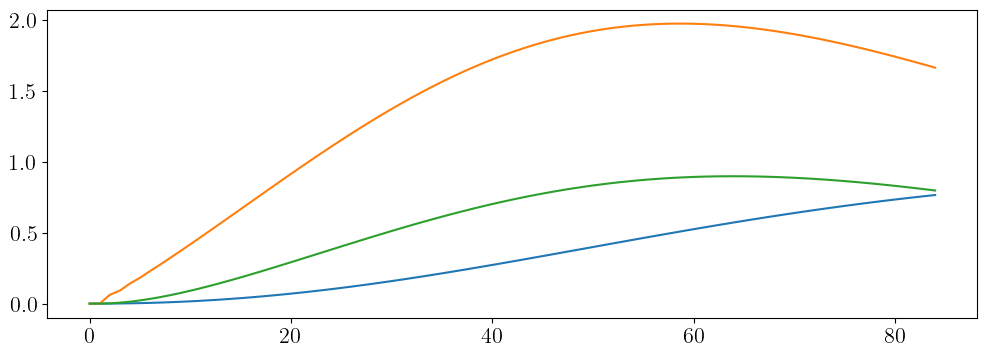

In [161]:
plt.plot(T_119_sp.T)

In [188]:
from numpy.linalg import matrix_rank
from scipy.linalg import eig, hankel

# ---------- helper utilities ----------
def _eig(A):                 # eigenvalues only, as a flat complex 1-D array
    return eig(A, left=False, right=False)


# ---------- 4) Nyquist / alias-free sampling ----------
def alias_free(A, dt):
    ω_max = np.max(np.abs(np.imag(_eig(A))))
    return (np.pi / dt) > ω_max + 1e-12    # strict inequality

# ---------- 5) record long enough to resolve slowest mode ----------
def window_long_enough(A, T_exp, factor=3.0):
    sigma_min = np.min(np.abs(np.real(_eig(A))))
    return T_exp * sigma_min >= factor

In [190]:
for scen in scenarios:
  print('Scenario:', scen)
  print('\tControllable:', controllable(A, F_wm[scen]))
  print('\tObservable:', observable(A, T_wm[scen]))
  #print('\tAlias Free:', alias_free(A, dt=1))
  print('\tLong Enough:', window_long_enough(A, len(T_wm[scen][0])))

Scenario: Abrupt
	Controllable: True
	Observable: True
	Persistently Exciting: False
	Long Enough: False
Scenario: SSP585
	Controllable: True
	Observable: True
	Persistently Exciting: False
	Long Enough: False
Scenario: SSP534
	Controllable: True
	Observable: True
	Persistently Exciting: False
	Long Enough: False
Scenario: SSP119
	Controllable: True
	Observable: True
	Persistently Exciting: False
	Long Enough: False


In [191]:
for scen in scenarios:
  print('Scenario:', scen)
  print('\tControllable:', controllable(A, F_sp[scen]))
  print('\tObservable:', observable(A, T_sp[scen]))
  print('\tPersistently Exciting:', persistently_exciting(F_sp[scen], n=A.shape[0]))
  #print('\tAlias Free:', alias_free(A, dt=1))
  print('\tLong Enough:', window_long_enough(A, len(T_sp[scen][0])))

Scenario: Abrupt
	Controllable: True
	Observable: True
	Persistently Exciting: False
	Long Enough: False
Scenario: SSP585
	Controllable: True
	Observable: True
	Persistently Exciting: False
	Long Enough: False
Scenario: SSP534
	Controllable: True
	Observable: True
	Persistently Exciting: False
	Long Enough: False
Scenario: SSP119
	Controllable: True
	Observable: True
	Persistently Exciting: False
	Long Enough: False


### 3) Quantitative tests for scenario usage

In [118]:
# ------------------------------------------------------------------
# 1.  robust pseudo-impulse
# ------------------------------------------------------------------
def forcing_pseudo_impulse(N, amp=0.5, width=1.0, box=0, start=None, use_year=True, dt_sec=None):
    """
    Short square pulse into a chosen box.
      width : pulse duration (time units) – will be ≥ 1 Δt internally
      start : index where pulse begins (defaults to N//4)
    """

    if not use_year:
        dt = dt_sec
    else:
        dt = 1

    F = np.zeros((3, N))
    w_steps = max(1, int(round(width / dt)))        # ensure ≥1 sample
    k0 = int(start) if start is not None else N // 4
    k1 = min(N, k0 + w_steps)
    mask = _box_mask(box)
    for i in range(3):
        F[i,k0 + 2*i*w_steps:k1 + 2*i*w_steps] += mask[i]*amp

    return F

# ------------------------------------------------------------
# 2. Step ↑ – hold – Step ↓
# ------------------------------------------------------------
# ------------------------------------------------------------------
# 2.  fixed step–hold–step  (already patched earlier)
# ------------------------------------------------------------------
def forcing_step_hold_step(N, amp=0.5, hold=5.0, box=None):
    F = np.zeros((3, N))
    k0 = N // 4
    k1 = k0 + max(1, hold)
    if k1 > N:
        k1 = N - 1
    mask = _box_mask(box)

    for i in range(3):
        F[i, k0 + i*hold//2:k1 + i*hold//2] += mask * amp          # step ↑ & hold
        F[i, k1 + i*hold//2:]  -= mask * amp          # step ↓
    return F


# ------------------------------------------------------------
# 3. Multi-sine / chirp
# ------------------------------------------------------------
def forcing_multi_sine(N, amps=(0.3, 0.3, 0.3), use_year=True, dt_sec=None):
    """
    freqs : iterable of *periods* in time units (converted to rad unit)
    amps  : per-frequency amplitudes (W m‒2)
    """
    if not use_year:
        dt = dt_sec
        freqs = (7851168000, 785116800, 785116800/2)
    else:
        dt = 1
        freqs = (5, 50, 200)

    t = np.arange(N) * dt
    F = np.zeros((3, N))
    for a, p in zip(amps, freqs):
        w = 2*np.pi / p
        F += a * np.sin(w * t)[None, :]

    if not use_year:
        F[1,:] = np.roll(F[1,:], 750)
        F[2,:] = np.roll(F[2,:], 1500)
    else:
        F[1,:] = np.roll(F[1,:], 60)
        F[2,:] = np.roll(F[2,:], 150)

    return F


# ------------------------------------------------------------
# 4. Pseudo-random binary sequence (PRBS)
# ------------------------------------------------------------
def forcing_prbs(N, dt, amp=0.5, clock=1, seed=None):
    """
    clock : duration of each PRBS bit in time units
    amp   : ±amp forcing
    """
    rng = np.random.default_rng(seed)
    n_bits = int(np.ceil(N*dt / clock))
    bits = rng.choice([-amp, amp], size=(3, n_bits))
    F = np.repeat(bits, repeats=int(clock/dt), axis=1)[:, :N]
    return F


# ------------------------------------------------------------
# 5. Gaussian white-noise forcing
# ------------------------------------------------------------
def forcing_white_noise(N, sigma=0.05, seed=None):
    rng = np.random.default_rng(seed)
    return rng.normal(0.0, sigma, size=(3, N))



In [163]:
def forcing_smooth_step(N, amp=0.5, hold=5.0, trans=1.0, box=None, use_year=True, dt_sec=None):

    if not use_year:
        dt = dt_sec
    else:
        dt = 1

    t = np.arange(N) * dt
    t0 = N//6 * dt                     # centre of up-transition
    t1 = t0 + hold                     # centre of down-transition

    # tanh ramps:  −½→+½  and  +½→−½
    up   = 0.5 * (1 + np.tanh((t - t0) / trans))
    down = 0.5 * (1 - np.tanh((t - t1) / trans))
    profile = amp * np.minimum(up, down)   # plateau with smooth edges

    F = np.zeros((3, N))
    mask = _box_mask(box)
    F += mask * profile                    # broadcast to chosen box(es)

    if not use_year:
        F[1,:] = np.roll(F[1,:], 750)
        F[2,:] = np.roll(F[2,:], 1500)
    else:
        F[1,:] = np.roll(F[1,:], 50)
        F[2,:] = np.roll(F[2,:], 100)
    return F

In [185]:
#N = t_vec.size
N = 650
t_vec2 = np.arange(N)

F_imp1 = forcing_pseudo_impulse(N, width=10, box=[0.5,0.75,1])
T_imp1 = three_box_ebm(C, Lam, F_imp1, t_vec2)

F_stephold1 = forcing_smooth_step(N, hold=50, trans=10, box=[0.5,0.75,1])
T_stephold1 = three_box_ebm(C, Lam, F_stephold1, t_vec2)

F_multisine1 = forcing_multi_sine(N, amps=(0.3, 0.3, 0.3))
T_multisine1 = three_box_ebm(C, Lam, F_multisine1, t_vec2)

F_white1 = forcing_white_noise(N, seed=1)
T_white1 = three_box_ebm(C, Lam, F_white1, t_vec2)

F_composite1 = F_white1 + forcing_smooth_step(N, hold=25, trans=10, box=[1.5,2.75,3.5])
T_composite1 = three_box_ebm(C, Lam, F_composite1, t_vec2)

#report = evaluate_forcing(A, F_composite1, dt)
#for k, v in report.items():
#  print(f"{k:15s}: {v}")

In [186]:
scenarios_ideal = ['pseudo','step','sine','gwn','composite']
Temps = [T_imp1, T_stephold1, T_multisine1, T_white1, T_composite1]
Fs = [F_imp1, F_stephold1, F_multisine1, F_white1, F_composite1]

F_ideal, T_ideal = {}, {}
for i, scen in enumerate(scenarios_ideal):
  F_ideal[scen] = Fs[i]
  T_ideal[scen] = Temps[i]

for scen in scenarios_ideal:
  print('Scenario:', scen)
  print('\tControllable:', controllable(A, F_ideal[scen]))
  print('\tObservable:', observable(A, T_ideal[scen]))
  print('\tPersistently Exciting:', persistently_exciting(F_ideal[scen], n=A.shape[0]))
  print('\tAlias Free:', alias_free(A, dt=1))
  print('\tLong Enough:', window_long_enough(A, len(T_ideal[scen][0])))

Scenario: pseudo
	Controllable: True
	Observable: True
	Persistently Exciting: True
	Alias Free: True
	Long Enough: True
Scenario: step
	Controllable: True
	Observable: True
	Persistently Exciting: True
	Alias Free: True
	Long Enough: True
Scenario: sine
	Controllable: True
	Observable: True
	Persistently Exciting: True
	Alias Free: True
	Long Enough: True
Scenario: gwn
	Controllable: True
	Observable: True
	Persistently Exciting: True
	Alias Free: True
	Long Enough: True
Scenario: composite
	Controllable: True
	Observable: True
	Persistently Exciting: True
	Alias Free: True
	Long Enough: True


Train: Abrupt - L2 Error
	Test: Abrupt - [6.14840808e-12 4.91215602e-13 1.17619405e-13]
	Test: SSP585 - [4.61103403 2.68288039 1.60329416]
	Test: SSP534 - [ 9.68662837  0.94301793 17.05253748]
	Test: SSP119 - [ 7.81284443 12.97423191 50.40747323]
Train: SSP585 - L2 Error
	Test: Abrupt - [4.11521113 2.51938287 1.24725159]
	Test: SSP585 - [1.04266450e-11 9.69023148e-13 2.27879428e-12]
	Test: SSP534 - [14.52456184  3.66936869 15.93348233]
	Test: SSP119 - [14.46704958 11.36281297 48.8461496 ]
Train: SSP534 - L2 Error
	Test: Abrupt - [ 9.6750815   0.80195031 16.58880352]
	Test: SSP585 - [14.85124695  1.85395298 16.53846553]
	Test: SSP534 - [1.84499198e-12 3.98939251e-13 1.68326493e-12]
	Test: SSP119 - [ 3.27188043 19.07605569 36.06190326]
Train: SSP119 - L2 Error
	Test: Abrupt - [31.38580558 31.65178116 39.18185049]
	Test: SSP585 - [36.53606451 32.4195509  43.44653657]
	Test: SSP534 - [21.95419783 30.20072453 26.91002966]
	Test: SSP119 - [3.63079063e-12 6.95389750e-13 1.93002506e-12]


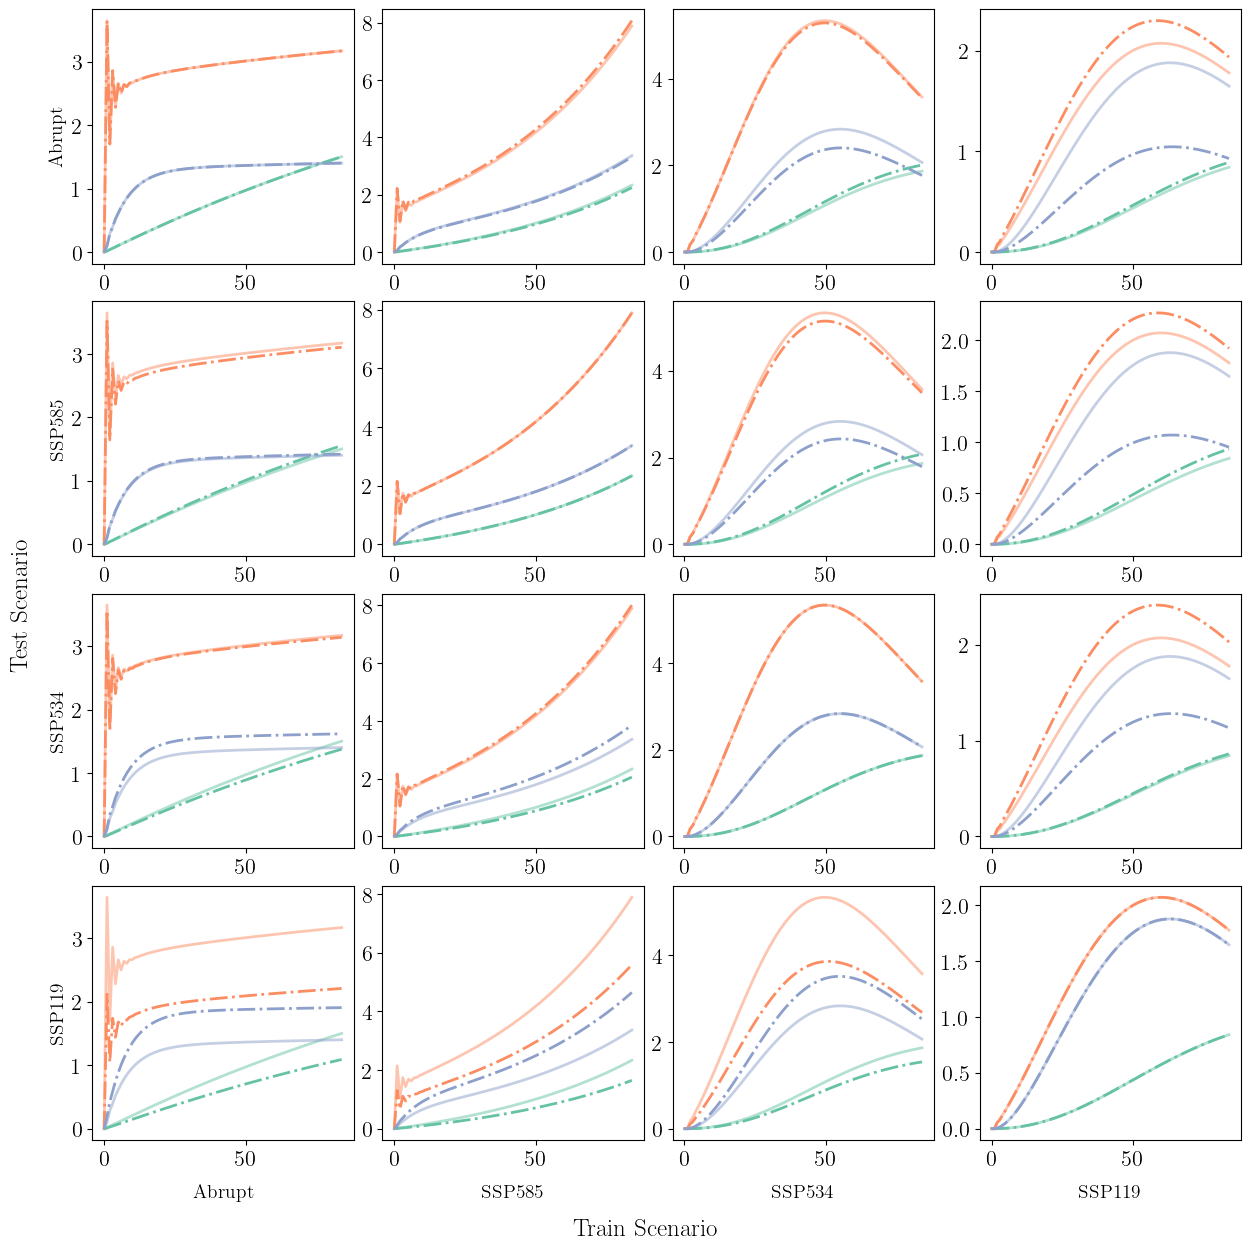

In [203]:
operator_DMD, T_pred_DMD, error_metrics_DMD = emulator_utils.emulate_scenarios('DMD', scenarios=scenarios, outputs=T_sp, forcings=F_sp, w0=np.array([0.0,0.0,0.0]), t=np.arange(85), dt=1, n_steps=85, n_boxes=3)
emulator_utils.plot_true_pred(T_sp, T_pred_DMD, scenarios)

Bbox(x0=0.5477272727272726, y0=0.6535294117647059, x1=0.8999999999999999, y1=0.88)
Bbox(x0=0.5347487006867692, y0=0.3481219621318873, x1=0.995833, y1=0.6599951827599565)
Bbox(x0=0.5347487006867692, y0=0.01864915470252612, x1=0.9958329999999999, y1=0.33416668204213723)


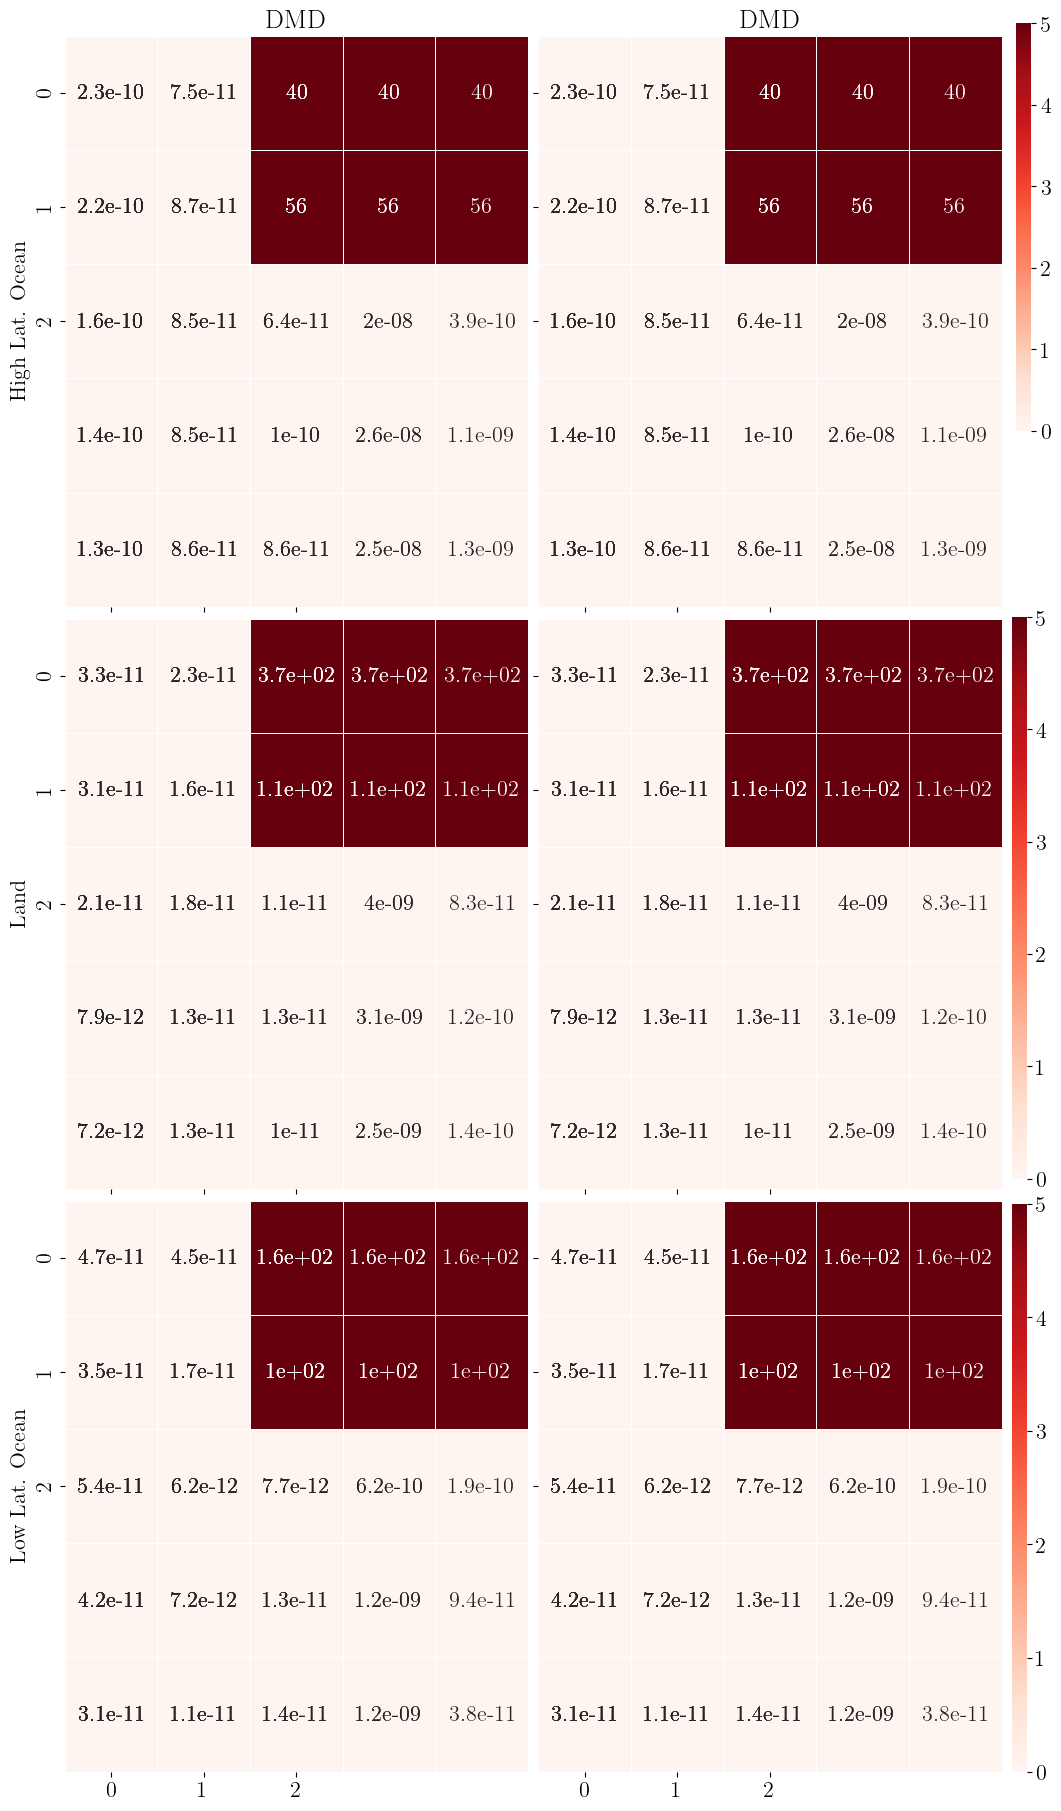

In [96]:
import run_all_exp

new_scens = ['pseudo','composite','abr','ove','exp']
run_all_exp.plot_error_heatmaps(error_metrics_DMD, '3box', regions, ['DMD','DMD'], new_scens, new_scens)

In [247]:
from scipy import sparse
from scipy.linalg import toeplitz
from scipy.sparse.linalg import spsolve_triangular

def method_1a_DMD(w, F):
  # Calculate L using DMD
  # Assume F is of size (nx, nt)
  Omega = np.concatenate([w[:,:-1],F[:,:-1]])
  L = w[:,1:] @ np.linalg.pinv(Omega)
  n = len(w)

  A_DMD, B_DMD = L[:,:n], L[:,n:]

  return A_DMD, B_DMD

def method_3a_deconvolve(w, F, dt, regularize=False):
  # Calculate G using deconvolution
  F_toep = sparse.csr_matrix(toeplitz(F[0,:], np.zeros_like(F[0,:])))
  G_deconv = spsolve_triangular(F_toep, w.T, lower=True)

  return G_deconv.T/dt

In [253]:
def emulate_DMD(F, A_DMD, B_DMD, w0, n_steps):
  # Emulate a scenario with DMD
  w_pred = np.zeros((w0.shape[0], n_steps))
  w_pred[:, 0] = w0

  for k in range(1, n_steps):
    w_pred[:, k] = A_DMD @ w_pred[:, k-1] + B_DMD @ F[:,k-1]

  return w_pred

In [248]:
A_composite1, B_composite1 = method_1a_DMD(T_composite1, F_composite1)
A_exp1, B_exp1 = method_1a_DMD(T_exp1, F_exp1)
#G = method_3a_deconvolve(T_wn, F5, dt_sec)

In [258]:
T_DMD_comp1 = emulate_DMD(F_stephold1, A_composite1, B_composite1, np.array([0.0,0.0,0.0]), N)
T_DMD_comp2 = emulate_DMD(F_stephold1, A_exp1, B_exp1, np.array([0.0,0.0,0.0]), N)

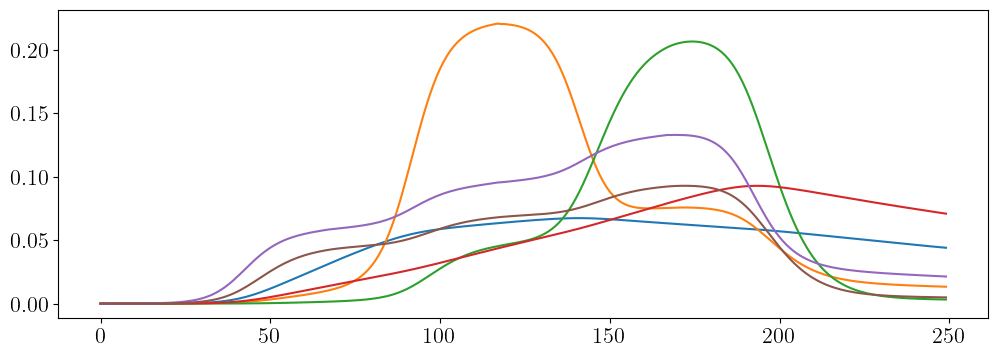

In [259]:
plt.plot(T_DMD_comp1.T)
plt.plot(T_DMD_comp2.T)

In [164]:
import numpy as np

def estimate_response(F, T, L=None, lam=0.0):
    Nx, Nt = F.shape
    L = Nt if L is None else L

    # Build block-Toeplitz design matrix A  (Nt × (nsrc·L))
    A = np.zeros((Nt, Nx * L))
    for n in range(Nt):
        for k in range(min(L, n + 1)):
            A[n, k * Nx:(k + 1) * Nx] = F[:, n - k]

    # Solve for each output location i independently
    R = np.empty((Nx, Nx, L))
    AtA = A.T @ A + lam * np.eye(Nx * L)
    At  = A.T
    for i in range(3):
        x = np.linalg.solve(AtA, At @ T[i])
        R[i] = x.reshape(L, Nx).T       # -> (nsrc, L)
    return R

def apply_response(F, R):

    Nx, Nt = F.shape
    L = R.shape[2]
    T_hat = np.zeros((3, Nt))
    for i in range(3):
        for j in range(Nx):
            T_hat[i] += np.convolve(F[j], R[i, j], mode="full")[:Nt]
    return T_hat


In [222]:
R_imp1 = estimate_response(F_imp1, T_imp1, lam=0.01)
R_stephold1 = estimate_response(F_stephold1, T_stephold1, lam=0.01)
R_multisine1 = estimate_response(F_multisine1, T_multisine1, lam=0.05)
R_white1 = estimate_response(F_white1, T_white1, lam=0.05)
R_composite1 = estimate_response(F_composite1, T_composite1, lam=1)

R_exp1 = estimate_response(F_exp1, T_exp1, lam=1)

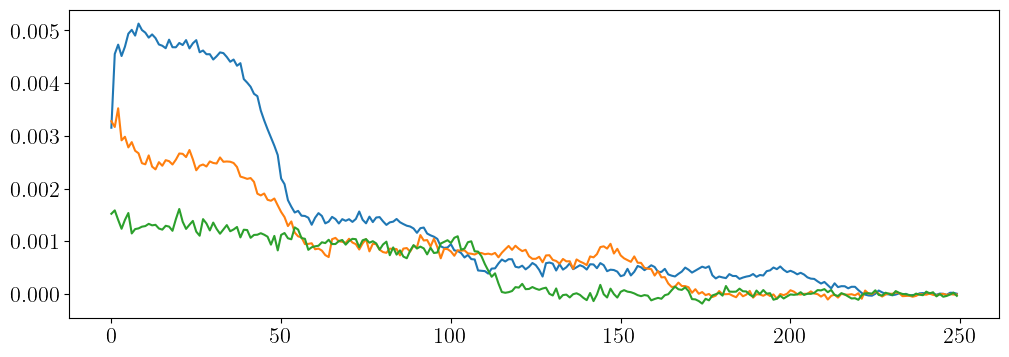

In [234]:
plt.plot(R_composite1[0,:,:].T)

In [158]:
def estimate_R_multi(F, T, L=None, lam=0.0):

    E, Nx, Nt = F.shape
    L = Nt if L is None else L

    # Build a single big design matrix  A_big = [A^exp1 ; A^exp2 ; ... ]
    rows   = []
    T_stk  = []
    for e in range(E):
        A = np.zeros((Nt, Nx * L))
        for n in range(Nt):
            for k in range(min(L, n + 1)):
                A[n, k*Nx:(k+1)*Nx] = F[e, :, n-k]
        rows.append(A)
        T_stk.append(T[e].reshape(3, Nt))   # keep i separate
    A_big = np.vstack(rows)                 # (E*Nt , nsrc*L)
    T_big = np.hstack(T_stk)                # (3 , E*Nt)

    # Shared left-hand term
    AtA = A_big.T @ A_big + lam*np.eye(Nx*L)
    At  = A_big.T

    R = np.empty((3, Nx, L))
    for i in range(3):
        x = np.linalg.solve(AtA, At @ T_big[i])
        R[i] = x.reshape(L, Nx).T
    return R


In [159]:
#R_multi = estimate_R_multi(np.stack([F4,F5,F6]), np.stack([T4,T5,T6]), lam = 0.25)
R_multi2 = estimate_R_multi(np.stack([F_exp1,F_abr1,F_ove1]), np.stack([T_exp1,T_abr1,T_ove1]), lam = 0.01)

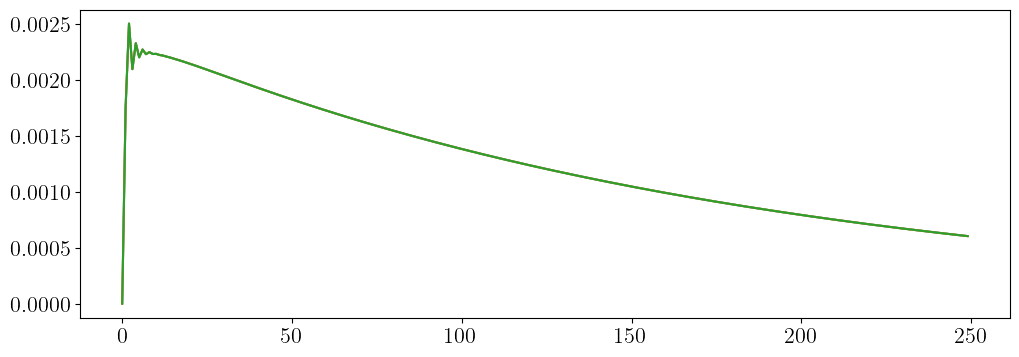

In [162]:
plt.plot(R_multi2[0,:,:].T)

In [728]:
def check_forcings(F, tol_cond=1e4):
    """
    F : (E, 3, Nt) array of forcings
    L : number of lags you plan to recover
    """
    E, N_s, N_t = F.shape
    Phi = F.reshape(E, -1)                       # (E , 3*Nt)

    rank   = np.linalg.matrix_rank(Phi)
    cond   = np.linalg.cond(Phi)
    svals  = np.linalg.svd(Phi, compute_uv=False)

    print(f"rank {rank}/{N_s},  cond {cond:.2e}")
    if rank < N_s:
        raise ValueError("Forcings are NOT linearly independent in space.")
    if cond > tol_cond:
        print("Warning: design matrix ill-conditioned; consider more diverse patterns.")

    # Optional: also check temporal rank for each channel
    for j in range(N_s):
        r = np.linalg.matrix_rank(F[:,j,:])
        if r < E:
            print(f"Channel {j} time shapes collinear across experiments.")

    return rank, cond, svals

check_forcings(F_exp)
#check_forcings(np.stack([F4,F5,F6]))
#check_forcings(np.stack([F_exp1,F_abr1,F_ove1]))

ValueError: not enough values to unpack (expected 3, got 2)

In [174]:
import numpy as np
from numpy.linalg import matrix_power               # discrete-time version
# from scipy.linalg import expm                    # uncomment for continuous-time

def L_to_response(L: np.ndarray, Nt: int) -> np.ndarray:
    R = np.empty((3, 3, Nt))
    M = np.eye(3)

    for k in range(Nt):
        R[:, :, k] = M          # store L^k
        M = M @ L               # update to L^(k+1)

        # For continuous-time, use:
        # R[:, :, k] = expm(L * k * dt)

    return R


In [270]:


def check_richness(T_snap, F_in, tol=1e-10):

    T_snap = _flatten(T_snap)             # (3 , N_total)
    F_in = _flatten(F_in)               # (3 , N_total)

    # ---------- state condition (snapshot matrix full-rank) ----------
    rank_state = np.linalg.matrix_rank(T_snap, tol)

    # ---------- input condition (input covariance full-rank) ----------
    Ru = F_in @ F_in.T / F_in.shape[1]          # ∫u uᵀ dt  (discrete mean)
    rank_input = np.linalg.matrix_rank(Ru, tol)

    return rank_state, rank_input, (rank_state == 3), (rank_input == 3)

In [271]:
print(check_richness(T_composite1, F_composite1))
print(check_richness(T_multisine1, F_multisine1))
print(check_richness(T_exp1, F_exp1))
print(check_richness(T_ove1, F_ove1))
print(check_richness(T_abr1, F_abr1))
print(check_richness(np.stack([T_exp1,T_abr1,T_ove1]), np.stack([F_exp1,F_abr1,F_ove1])))

(np.int64(3), np.int64(3), np.True_, np.True_)
(np.int64(3), np.int64(3), np.True_, np.True_)
(np.int64(3), np.int64(1), np.True_, np.False_)
(np.int64(3), np.int64(1), np.True_, np.False_)
(np.int64(3), np.int64(1), np.True_, np.False_)
(np.int64(3), np.int64(3), np.True_, np.True_)


In [272]:
F_all = np.concatenate([F_exp1, F_abr1, F_ove1], axis=1)   # (3 , 3N)
T_all = np.concatenate([T_exp1, T_abr1, T_ove1], axis=1)   # (3 , 3N)
check_richness(T_all, F_all)

(np.int64(3), np.int64(1), np.True_, np.False_)